# 📐 线性代数与微积分基础（Day 10）

> 本笔记覆盖机器学习所需的**线性代数**（向量、矩阵、线性变换、特征值、SVD、PCA）与**微积分**（梯度、Jacobian、Hessian）两大块。
> 视频对照来自 **3Blue1Brown《线性代数的本质》** 与 **《微积分的本质》**。

**上午（3h）：**

1. 向量与矩阵运算、点积、矩阵乘法
2. 线性变换的几何理解（用 matplotlib 可视化）
3. 特征值与特征向量

**下午（3h）：**

4. 矩阵分解：SVD、PCA 降维原理
5. 用 NumPy 从零实现 PCA
6. 梯度、Jacobian 矩阵、Hessian 矩阵简介

**📺 视频对照表：**

| 知识点 | 视频 |
| --- | --- |
| 向量、点积 | 07 点积与对偶性 → https://www.bilibili.com/video/BV1ys411472E/?p=10 |
| 线性变换的几何理解 | 03 矩阵与线性变换 → https://www.bilibili.com/video/BV1ys411472E/?p=4 |
| 矩阵乘法 | 04 矩阵乘法与线性变换复合 → https://www.bilibili.com/video/BV1ys411472E/?p=5 |
| 特征值与特征向量 | 10 特征向量与特征值 → https://www.bilibili.com/video/BV1ys411472E/?p=14 |
| 基变换（PCA 思想基础） | 09 基变换 → https://www.bilibili.com/video/BV1ys411472E/?p=13 |
| 梯度 / Jacobian | 《微积分的本质》→ https://www.bilibili.com/video/av24325548/ 与多元微积分 part11 → https://www.bilibili.com/video/av590724682/ |

> ⚠️ **说明**：3Blue1Brown 线代系列**没有单独讲 SVD 和 PCA**，最接近的基础是「特征值（P14）」+「基变换（P13）」两集；
> 所以下午的 SVD / PCA 部分**主要靠 NumPy 自己动手实现**。Hessian 也没有专门一集，把「高阶导数」+ Jacobian 看懂后自然能推。

> ⚠️ **运行提示**：请从第一个代码单元格开始**按顺序**运行，后面的代码会用到前面定义好的变量与函数。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# 让 matplotlib 能正常显示中文（Windows 常见字体）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False   # 让负号 "-" 正常显示

# 本笔记统一使用的颜色（与 Day9 风格一致）
蓝 = '#2b7bba'
橙 = '#e69f00'
灰 = '#999999'

def 显示动画(fig, update, frames, interval=50):
    """把 FuncAnimation 转成 notebook 里可以直接播放的内联动画。"""
    ani = animation.FuncAnimation(fig, update, frames=frames, interval=interval)
    html = ani.to_jshtml()
    plt.close(fig)
    return HTML(html)

print("✓ 环境准备完成（含动画支持）")

✓ 环境准备完成（含动画支持）


In [2]:
# ---- 本笔记反复用到的绘图工具函数 ----

def 画网格(ax, A=None, 范围=(-4, 4), 密度=1.0):
    """画网格。A=None 时画标准网格；给定 A 则画 A 变换后的网格。"""
    x = np.arange(范围[0], 范围[1] + 密度, 密度)
    for k in x:
        for pts in [np.array([[k, 范围[0]], [k, 范围[1]]]),     # 竖线 x=k
                    np.array([[范围[0], k], [范围[1], k]])]:     # 横线 y=k
            if A is not None:
                pts = pts @ A.T     # 每个点（行向量）右乘 A 的转置 = 左乘 A
            ax.plot(pts[:, 0], pts[:, 1], color=灰, lw=0.7)

def 画基向量(ax, A=None):
    """画基向量 î(橙) 和 ĵ(蓝)；给定 A 时画变换后的基向量。"""
    e1, e2 = np.array([1., 0.]), np.array([0., 1.])
    if A is not None:
        e1, e2 = A @ e1, A @ e2
    for e, c in [(e1, 橙), (e2, 蓝)]:
        ax.arrow(0, 0, e[0], e[1], head_width=0.13, head_length=0.13,
                 length_includes_head=True, fc=c, ec=c, lw=2.2)

def 可视化线性变换(A, 标题="线性变换", 范围=(-4, 4), 密度=1.0):
    """左图：变换前；右图：A 作用后。矩阵的每一列 = 变换后的基向量。"""
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 5))
    for ax in (ax0, ax1):
        ax.set_xlim(*范围); ax.set_ylim(*范围)
        ax.set_aspect('equal')
        ax.axhline(0, color='k', lw=0.7); ax.axvline(0, color='k', lw=0.7)
        ax.set_xticks(np.arange(范围[0], 范围[1] + 1))
        ax.set_yticks(np.arange(范围[0], 范围[1] + 1))
    ax0.set_title('变换前（标准基 i, j）')
    ax1.set_title('变换后（矩阵 A 作用后）')
    画网格(ax0, None, 范围, 密度)
    画网格(ax1, A, 范围, 密度)
    画基向量(ax0, None)
    画基向量(ax1, A)
    fig.suptitle(标题, fontsize=13)
    plt.tight_layout()
    plt.show()

def 画单位正方形变换(A, 标题):
    """行列式 = 面积的缩放倍数：看单位正方形 [0,1]² 在 A 下的面积变化。"""
    角 = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])
    变换后 = 角 @ A.T
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))
    for ax in (ax0, ax1):
        ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
        ax.set_aspect('equal'); ax.grid(alpha=0.3)
        ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)
    ax0.plot(角[:, 0], 角[:, 1], color=蓝, lw=3)
    ax0.fill(角[:, 0], 角[:, 1], color=蓝, alpha=0.2)
    ax0.set_title('变换前：面积 = 1')
    ax1.plot(变换后[:, 0], 变换后[:, 1], color=橙, lw=3)
    ax1.fill(变换后[:, 0], 变换后[:, 1], color=橙, alpha=0.2)
    det = np.linalg.det(A)
    ax1.set_title(f'变换后：面积 = |det| = {abs(det):.2f}  (det = {det:.2f})')
    plt.tight_layout()
    plt.show()

def 变换动画(A, 标题="矩阵作用：网格连续变形", 范围=(-3, 3), 密度=1.0, 步数=60):
    """从恒等变换连续过渡到 A，模拟 3Blue1Brown 的经典网格变形动画。"""
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.set_xlim(*范围); ax.set_ylim(*范围); ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.7); ax.axvline(0, color='k', lw=0.7)
    ax.set_xticks(np.arange(范围[0], 范围[1] + 1))
    ax.set_yticks(np.arange(范围[0], 范围[1] + 1))

    x = np.arange(范围[0], 范围[1] + 密度, 密度)
    线们 = []
    for k in x:
        l1, = ax.plot([], [], color=灰, lw=0.8)
        l2, = ax.plot([], [], color=灰, lw=0.8)
        线们.append((l1, l2, k))

    e1线, = ax.plot([], [], color=橙, lw=2.5)
    e2线, = ax.plot([], [], color=蓝, lw=2.5)
    title = ax.set_title('', fontsize=12)

    I = np.eye(2)
    ts = np.linspace(0, 1, 步数)

    def update(i):
        M = (1 - ts[i]) * I + ts[i] * A     # 在恒等变换与 A 之间插值
        for l1, l2, k in 线们:
            p_v = np.array([[k, 范围[0]], [k, 范围[1]]]) @ M.T
            p_h = np.array([[范围[0], k], [范围[1], k]]) @ M.T
            l1.set_data(p_v[:, 0], p_v[:, 1])
            l2.set_data(p_h[:, 0], p_h[:, 1])
        e1 = M @ np.array([1., 0.]); e2 = M @ np.array([0., 1.])
        e1线.set_data([0, e1[0]], [0, e1[1]])
        e2线.set_data([0, e2[0]], [0, e2[1]])
        title.set_text(f'{标题}  t = {ts[i]:.2f}')
        return [l1 for l1, _, _ in 线们] + [l2 for _, l2, _ in 线们] + [e1线, e2线, title]

    return 显示动画(fig, update, frames=步数, interval=40)

print("✓ 工具函数就绪")

✓ 工具函数就绪


# ☀️ 上午部分：线性代数

## 1. 向量与矩阵运算

**向量**可以理解成"空间里的一个箭头"，有**长度**和**方向**。在机器学习里，一条样本（比如一张图的全部像素、一行表格数据）常常就被摆成一个向量。

二维向量 $\vec{v} = \begin{bmatrix}3\\2\end{bmatrix}$ 表示：从原点出发，向右走 3、向上走 2。

三种最基本的运算：

- **加法**：$\vec{v}+\vec{w}$ 分量相加，几何上就是"首尾相接"或"平行四边形对角线"；
- **数乘**：$k\vec{v}$ 把向量整体拉长/缩短（$k<0$ 还会反向）；
- **点积（内积）**：$\vec{v}\cdot\vec{w}=v_1w_1+v_2w_2$，得到一个**数**，后面单独讲它的几何意义。


向量 v = [3 2]    向量 w = [-1  2]
v + w  = [2 4]
2 * v  = [6 4]
v - w  = [4 0]
|v|（长度）= 3.6056


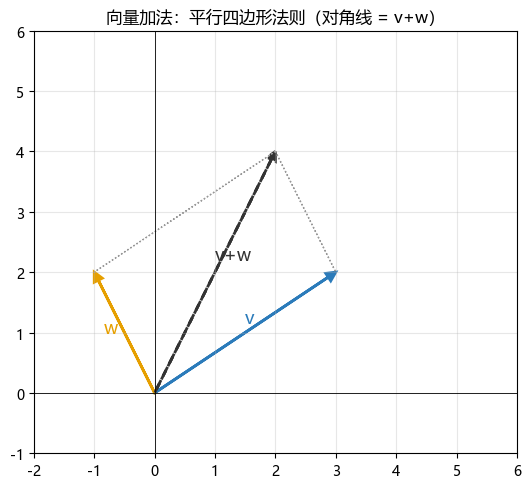

In [3]:
# ---- 向量基本运算 ----
v = np.array([3, 2])
w = np.array([-1, 2])

print("向量 v =", v, "   向量 w =", w)
print("v + w  =", v + w)          # 加法：分量相加（平行四边形法则）
print("2 * v  =", 2 * v)          # 数乘：整体缩放
print("v - w  =", v - w)          # 减法
print("|v|（长度）= %.4f" % np.linalg.norm(v))   # 范数 = sqrt(3^2 + 2^2)

# 可视化 v、w、v+w（平行四边形法则）
fig, ax = plt.subplots(figsize=(6, 5))
ax.set_xlim(-2, 6); ax.set_ylim(-1, 6)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)

ax.arrow(0, 0, v[0], v[1], head_width=0.15, head_length=0.15, fc=蓝, ec=蓝, length_includes_head=True, lw=2)
ax.arrow(0, 0, w[0], w[1], head_width=0.15, head_length=0.15, fc=橙, ec=橙, length_includes_head=True, lw=2)
ax.arrow(0, 0, (v+w)[0], (v+w)[1], head_width=0.15, head_length=0.15, fc='#333333', ec='#333333', length_includes_head=True, lw=2, ls='--')
ax.arrow(w[0], w[1], v[0], v[1], head_width=0, head_length=0, fc=灰, ec=灰, lw=1, ls=':')
ax.arrow(v[0], v[1], w[0], w[1], head_width=0, head_length=0, fc=灰, ec=灰, lw=1, ls=':')

ax.text(v[0]*0.5, v[1]*0.5+0.15, 'v', color=蓝, fontsize=13)
ax.text(w[0]*0.5-0.35, w[1]*0.5, 'w', color=橙, fontsize=13)
ax.text((v+w)[0]*0.5, (v+w)[1]*0.5+0.2, 'v+w', color='#333333', fontsize=13)
ax.set_title('向量加法：平行四边形法则（对角线 = v+w）')
plt.tight_layout()
plt.show()

## 2. 点积（内积）：一个数，藏着"投影"

$$\vec{v}\cdot\vec{w} = v_1w_1 + v_2w_2 = |\vec{v}||\vec{w}|\cos\theta$$

两个向量点积，得到的是一个**标量**。第二种写法揭示了它的几何意义：

- $\cos\theta$ 是两向量夹角的余弦；
- 所以 $\vec{v}\cdot\vec{w}$ = **$\vec{w}$ 在 $\vec{v}$ 方向上的投影长度 × $|\vec{v}|$**（也对称地等于 $\vec{v}$ 在 $\vec{w}$ 上投影 × $|\vec{w}|$）。

三个结论要记牢：

- 点积 $> 0$ → 夹角 < 90°（方向大致相同）；
- 点积 $= 0$ → 两向量**垂直（正交）**（机器学习的"正交、解耦"都源自这里）；
- 点积 $< 0$ → 夹角 > 90°（方向大致相反）。

> 📺 **对偶性 (duality)**：3Blue1Brown 的核心洞察是——"与一个向量 $\vec{v}$ 做点积"这件事，本身就是一个**线性变换**（把二维向量压成一个数，即 $\mathbb{R}^2\to\mathbb{R}$）。
> 而任何从 $\mathbb{R}^n\to\mathbb{R}$ 的线性变换，都能表示成一个 **1×n 的行矩阵**；这个行矩阵，恰好就是 $\vec{v}$ 转置过来的。这就是"点积"和"线性变换"之间的对偶关系。


In [4]:
# ---- 点积（内积）计算 ----
v = np.array([3, 1])
w = np.array([1, 2])

点积 = np.dot(v, w)                # 3*1 + 1*2 = 5
cosθ = 点积 / (np.linalg.norm(v) * np.linalg.norm(w))
夹角 = np.degrees(np.arccos(cosθ))

print(f"v·w = {点积}  （分量相乘再相加：3×1 + 1×2）")
print(f"|v| = {np.linalg.norm(v):.3f},  |w| = {np.linalg.norm(w):.3f}")
print(f"v·w = |v||w|·cosθ  →  cosθ = {cosθ:.3f}  →  夹角 θ = {夹角:.1f}°")
print(f"验证 |v||w|cosθ = {np.linalg.norm(v) * np.linalg.norm(w) * cosθ:.3f}  ✓")

v·w = 5  （分量相乘再相加：3×1 + 1×2）
|v| = 3.162,  |w| = 2.236
v·w = |v||w|·cosθ  →  cosθ = 0.707  →  夹角 θ = 45.0°
验证 |v||w|cosθ = 5.000  ✓


w 在 v 方向上的投影长度 = 1.581
点积 = 投影长度 × |v| = 1.581 × 3.162 = 5.000


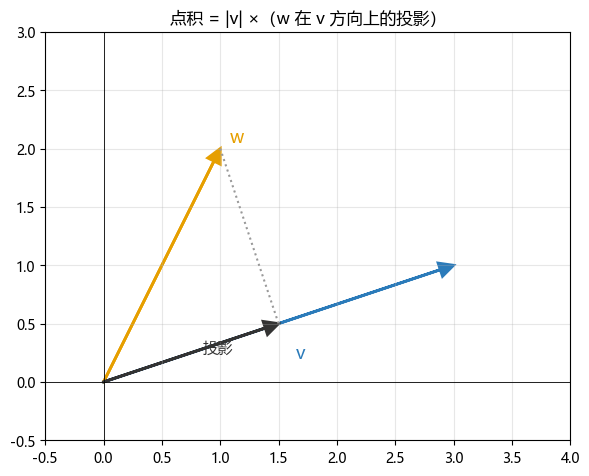

In [5]:
# ---- 点积的几何意义：w 在 v 方向上的投影 ----
v = np.array([3, 1])
w = np.array([1, 2])
vhat = v / np.linalg.norm(v)            # v 方向上的单位向量
投影标量 = np.dot(w, vhat)              # w 在 v 方向上的投影长度（带符号）
投影向量 = 投影标量 * vhat              # 投影出来的那个向量

print(f"w 在 v 方向上的投影长度 = {投影标量:.3f}")
print(f"点积 = 投影长度 × |v| = {投影标量:.3f} × {np.linalg.norm(v):.3f} = {投影标量*np.linalg.norm(v):.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 3)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)

ax.arrow(0, 0, v[0], v[1], head_width=0.12, head_length=0.12, fc=蓝, ec=蓝, length_includes_head=True, lw=2)
ax.arrow(0, 0, w[0], w[1], head_width=0.12, head_length=0.12, fc=橙, ec=橙, length_includes_head=True, lw=2)
ax.arrow(0, 0, 投影向量[0], 投影向量[1], head_width=0.12, head_length=0.12, fc='#333333', ec='#333333', length_includes_head=True, lw=2)
ax.plot([w[0], 投影向量[0]], [w[1], 投影向量[1]], color=灰, ls=':', lw=1.5)

ax.text(v[0]*0.55, v[1]*0.55-0.35, 'v', color=蓝, fontsize=13)
ax.text(w[0]+0.08, w[1]+0.05, 'w', color=橙, fontsize=13)
ax.text(投影向量[0]*0.5+0.1, 投影向量[1]*0.5, '投影', color='#333333', fontsize=11)
ax.set_title('点积 = |v| ×（w 在 v 方向上的投影）')
plt.tight_layout()
plt.show()

## 3. 矩阵：一堆数 + 一个"动作"

**矩阵**就是一个二维数表（NumPy 里的二维 `ndarray`）。它既可以看成"装数据的容器"，更本质的视角是——**矩阵 = 线性变换**（第 4 节展开）。

先看它作为"数表"的基本运算：

- **加减**：形状相同，逐元素相加；
- **数乘**：每个元素都乘同一个数；
- **转置 $A^T$**：行列互换（$A^T_{ij}=A_{ji}$）；
- **逆 $A^{-1}$**：满足 $AA^{-1}=I$ 的矩阵（只有"方阵且行列式不为 0"才有逆）。


In [6]:
# ---- 矩阵基本运算 ----
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print("矩阵 A =\n", A)
print("A + B =\n", A + B)            # 逐元素相加
print("3 * A =\n", 3 * A)            # 数乘
print("A 的转置 A.T =\n", A.T)        # 转置：行列互换
print("A 的逆 inv(A) =\n", np.linalg.inv(A))
print("A · A⁻¹ =\n", np.round(A @ np.linalg.inv(A), 10))   # 单位矩阵

# 形状（shape）在机器学习里极其重要：批量数据常常是 (样本数, 特征数)
X = np.random.randn(100, 4)
print("\n示例：100 条样本、4 个特征的数据矩阵 shape =", X.shape)

矩阵 A =
 [[1 2]
 [3 4]]
A + B =
 [[ 6  8]
 [10 12]]
3 * A =
 [[ 3  6]
 [ 9 12]]
A 的转置 A.T =
 [[1 3]
 [2 4]]
A 的逆 inv(A) =
 [[-2.   1. ]
 [ 1.5 -0.5]]
A · A⁻¹ =
 [[1. 0.]
 [0. 1.]]



示例：100 条样本、4 个特征的数据矩阵 shape = (100, 4)


## 4. 矩阵乘法 = 线性变换的复合

$$\underbrace{A\,(B\,\vec{x})}_{\text{先 B 后 A}} \;=\; \underbrace{(AB)\,\vec{x}}_{\text{用一个矩阵表示}}$$

**核心直觉**：矩阵乘法 $AB$ 表示"**先做 $B$，再做 $A$**"的**复合变换**。

- $(AB)_{ij}$ 的每个元素，是 $A$ 的第 $i$ 行与 $B$ 的第 $j$ 列的**点积**；
- **顺序极其重要**：一般 $AB \ne BA$（变换不交换）；
- 形状要求：$A$ 是 $m\times n$、$B$ 是 $n\times p$，相乘得到 $m\times p$。


In [7]:
# ---- 矩阵乘法 = 复合变换 ----
A = np.array([[0, -1], [1, 0]])     # 逆时针旋转 90°
B = np.array([[2, 0], [0, 2]])      # 均匀放大 2 倍

x = np.array([1.0, 0.5])            # 一个向量

先旋转再放大 = B @ (A @ x)          # (B A) x：先 A 后 B
先放大再旋转 = A @ (B @ x)          # (A B) x：先 B 后 A

print("原向量 x         =", x)
print("(B·A) x  先旋转再放大 =", 先旋转再放大)
print("(A·B) x  先放大再旋转 =", 先放大再旋转)
print("→ 均匀放大(是单位阵的倍数)与任何变换都可交换，所以这里结果相同。")

# 一个不可交换的例子
P = np.array([[1, 0], [0, 0]])     # 压平 y 轴（投影到 x 轴）
R = np.array([[0, -1], [1, 0]])    # 旋转 90°
print("\n压平再旋转  P·R =\n", P @ R)
print("旋转再压平  R·P =\n", R @ P)
print("→ 结果完全不同！矩阵乘法顺序不能随便换。")

原向量 x         = [1.  0.5]
(B·A) x  先旋转再放大 = [-1.  2.]
(A·B) x  先放大再旋转 = [-1.  2.]
→ 均匀放大(是单位阵的倍数)与任何变换都可交换，所以这里结果相同。

压平再旋转  P·R =
 [[ 0 -1]
 [ 0  0]]
旋转再压平  R·P =
 [[0 0]
 [1 0]]
→ 结果完全不同！矩阵乘法顺序不能随便换。


## 5. 线性变换的几何理解（重点）

3Blue1Brown 的招牌观点：**"矩阵不是一堆数字，而是一个把空间'揉捏'的动作。"**

一个变换是**线性**的，当且仅当满足两条：

1. 直线变换后仍是直线（不弯曲）；
2. 原点保持不动。

**最关键的结论**：二维线性变换**完全由两个基向量 $\hat{i}=(1,0)$、$\hat{j}=(0,1)$ 的去向决定**。
因为任意向量 $\vec{v}=x\hat{i}+y\hat{j}$，变换后就是 $x\cdot(\text{新 }\hat{i})+y\cdot(\text{新 }\hat{j})$。

于是矩阵的**每一列，就是变换后的基向量**：

$$A=\begin{bmatrix}a&b\\c&d\end{bmatrix}\quad\Rightarrow\quad \text{新 }\hat{i}=\begin{bmatrix}a\\c\end{bmatrix},\ \text{新 }\hat{j}=\begin{bmatrix}b\\d\end{bmatrix}$$

下面用几张图直观感受几种经典变换。


C:\Users\HP\AppData\Local\Temp\ipykernel_21544\2243443092.py:38: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


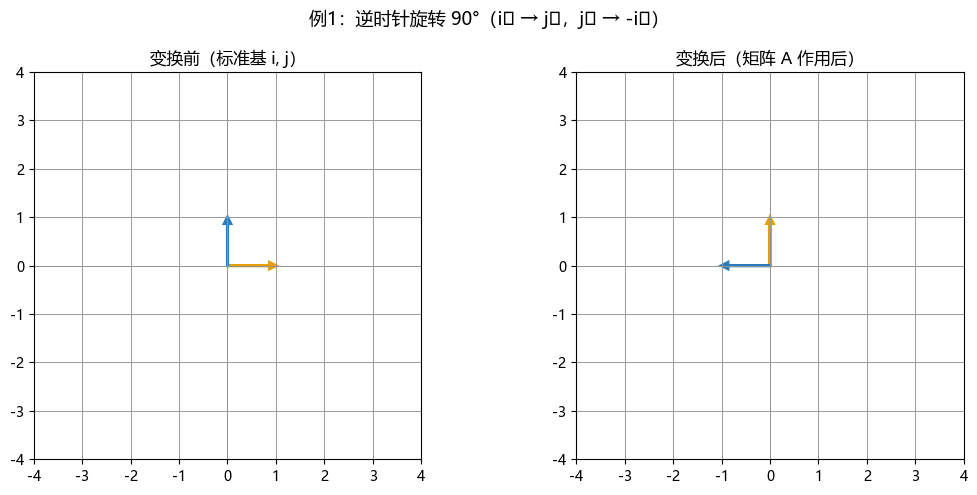

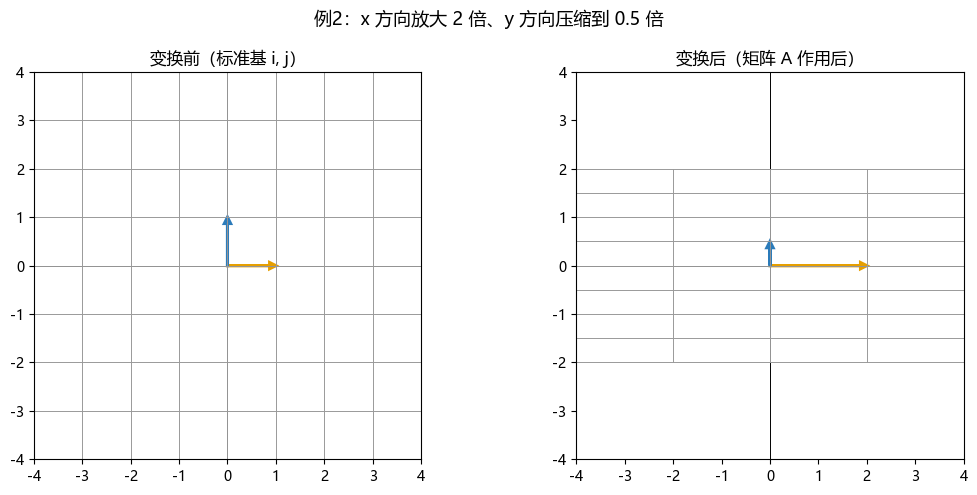

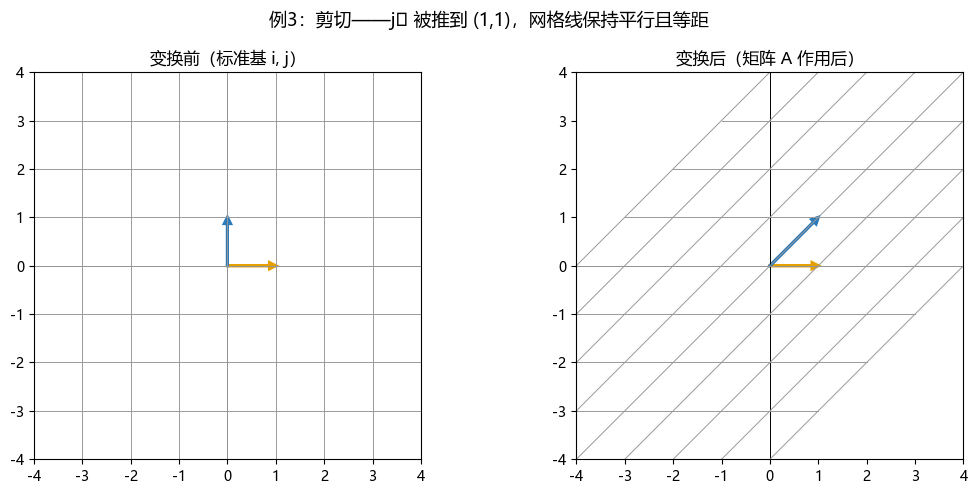

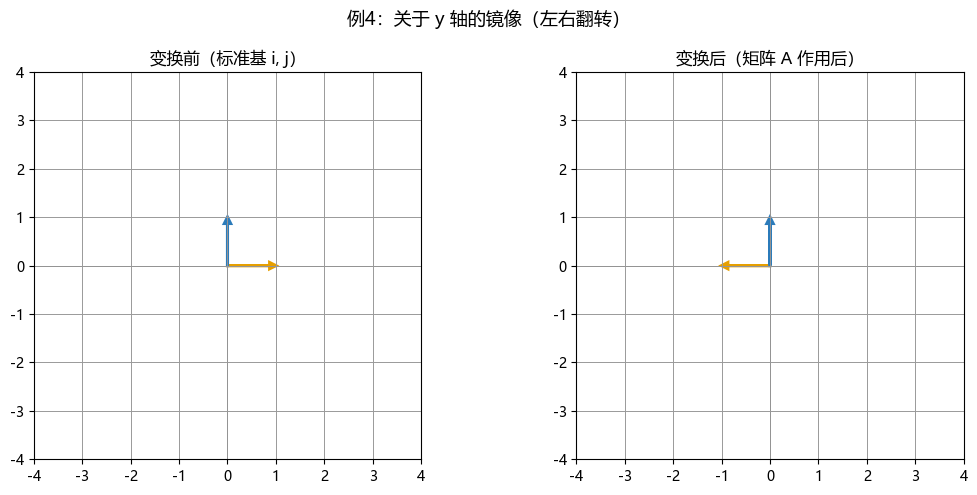

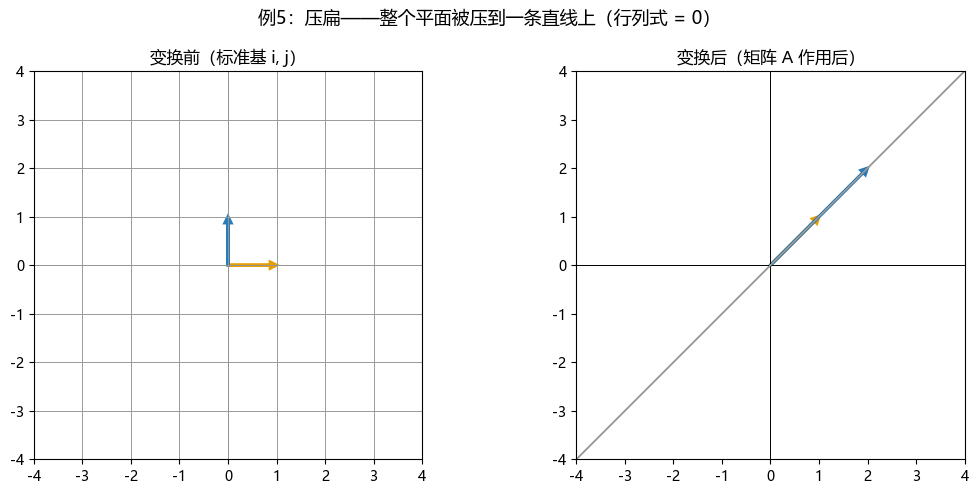

det(压扁) = 0.0 → 面积为 0，空间被'降维'了


In [8]:
# ---- 例1：逆时针旋转 90° ----
旋转90 = np.array([[0, -1], [1, 0]])   # î 转到 (0,1)，ĵ 转到 (-1,0)
可视化线性变换(旋转90, "例1：逆时针旋转 90°（î → ĵ，ĵ → -î）")

# ---- 例2：缩放（不均匀拉伸）----
缩放 = np.array([[2, 0], [0, 0.5]])
可视化线性变换(缩放, "例2：x 方向放大 2 倍、y 方向压缩到 0.5 倍")

# ---- 例3：剪切（shear）----
剪切 = np.array([[1, 1], [0, 1]])       # ĵ 被"推"到 (1,1)，网格线仍平行
可视化线性变换(剪切, "例3：剪切——ĵ 被推到 (1,1)，网格线保持平行且等距")

# ---- 例4：镜像（关于 y 轴翻转）----
镜像 = np.array([[-1, 0], [0, 1]])
可视化线性变换(镜像, "例4：关于 y 轴的镜像（左右翻转）")

# ---- 例5：压扁（行列式为 0，二维被压成一维）----
压扁 = np.array([[1, 2], [1, 2]])        # 两列线性相关
可视化线性变换(压扁, "例5：压扁——整个平面被压到一条直线上（行列式 = 0）")
print("det(压扁) =", round(np.linalg.det(压扁), 6), "→ 面积为 0，空间被'降维'了")

### 行列式 = 面积的缩放倍数

**行列式 $\det(A)$** 衡量一个线性变换把面积/体积**放大多少倍**：

- $\det > 0$：保持朝向（右手系）；$\det < 0$：翻转朝向；
- $\det = 0$：空间被"压扁"（降维），此时 $A$ 不可逆；
- $|\det(AB)| = |\det A|\cdot|\det B|$（复合变换的面积倍数 = 两个倍数相乘）。

看单位正方形 $[0,1]^2$ 在各种变换下的面积变化，一目了然：


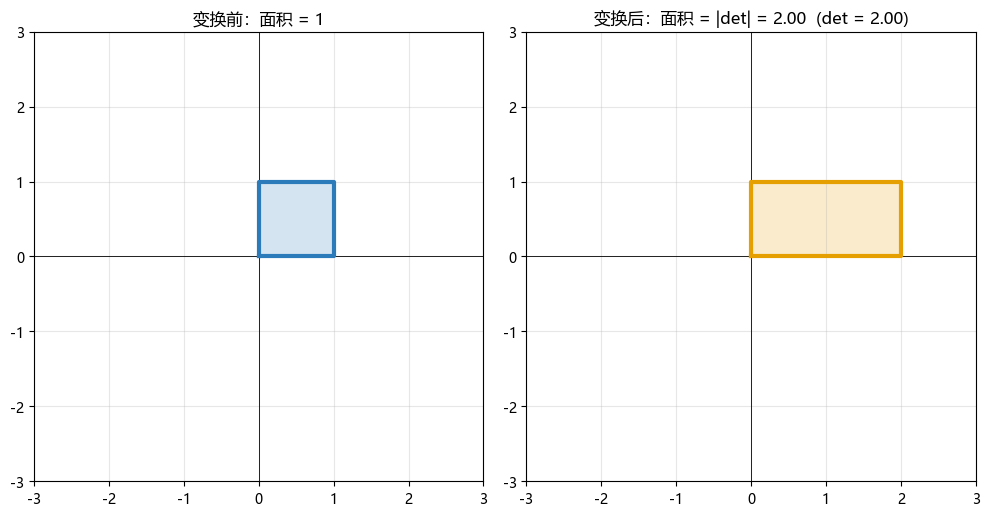

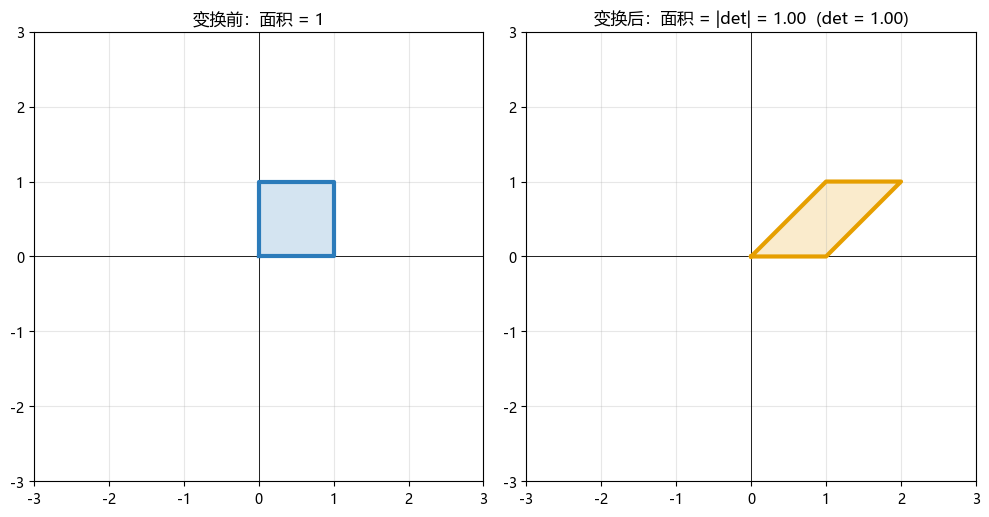

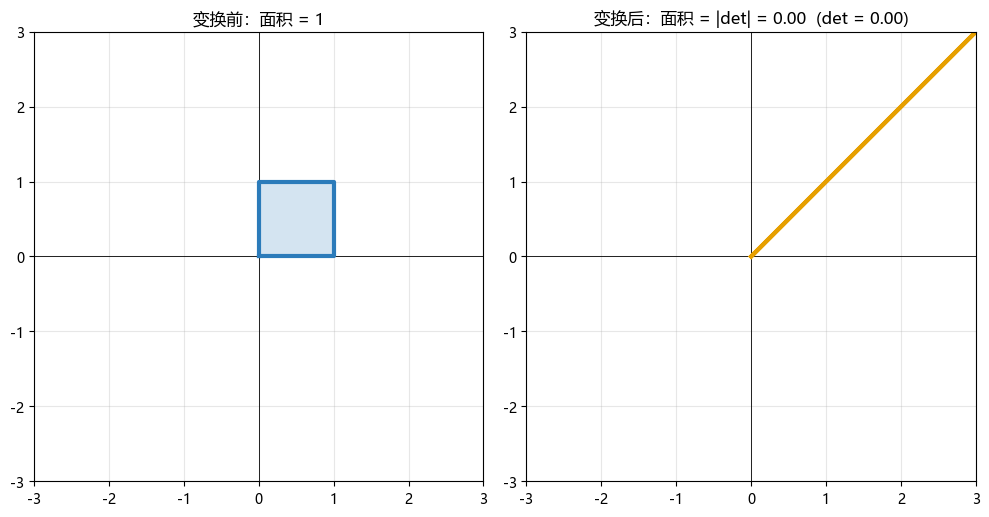

In [9]:
画单位正方形变换(np.array([[2, 0], [0, 1]]), "x 方向放大 2 倍 → 面积 ×2")
画单位正方形变换(np.array([[1, 1], [0, 1]]), "剪切 → 面积不变（平行四边形面积 = 底×高）")
画单位正方形变换(np.array([[1, 2], [1, 2]]), "压扁 → 面积 = 0（行列式为 0，不可逆）")

### 🎬 动画：网格连续变形

下面把"变换"做成动画——网格从标准状态**连续过渡**到矩阵作用后的状态，这就是 3Blue1Brown 里最经典的那个画面。把 `A` 换成任何矩阵都能看到对应的变形。


In [2]:
# 旋转 90°：整个平面像转盘一样转过去
变换动画(旋转90, "逆时针旋转 90°")

NameError: name '变换动画' is not defined

In [3]:
# 剪切：网格"歪"过去，但每条线始终是直线、且保持平行
变换动画(剪切, "剪切变换：ĵ 被推向 (1,1)")

NameError: name '变换动画' is not defined

## 6. 特征值与特征向量

大多数向量经过线性变换后，方向都变了；但有些"特殊的向量"，变换后**方向不变，只是被拉伸/压缩了一个倍数**：

$$A\vec{v} = \lambda \vec{v}$$

- $\vec{v}$ 叫**特征向量 (eigenvector)**——方向被 $A$ "保留下"的方向；
- $\lambda$ 叫**特征值 (eigenvalue)**——沿这个方向被拉伸的倍数（可以为负=反向，为 0=被压没）。

**为什么重要？** 因为特征向量揭示了变换"本质上的轴"：

- 旋转矩阵的特征值是复数（没有方向完全不变的实向量）；
- 对称矩阵（协方差矩阵就是！）的特征向量**互相垂直**、特征值全为**实数**——这正是 PCA 的地基；
- 特征值还能判断稳定性、主成分方差大小等。

**求解**：解特征方程 $\det(A-\lambda I)=0$ 得到 $\lambda$，再解 $(A-\lambda I)\vec{v}=0$ 得到 $\vec{v}$。NumPy 一行搞定。


In [12]:
# ---- 特征值与特征向量 ----
A = np.array([[2, 1], [1, 2]])      # 对称矩阵，特征值一定是实数

特征值, 特征向量 = np.linalg.eig(A)
print("特征值 λ =\n", 特征值)
print("特征向量（每列一个）=\n", 特征向量)

# 验证 A·v = λ·v
for i in range(2):
    λ = 特征值[i]; v = 特征向量[:, i]
    print(f"\n第 {i+1} 个：λ = {λ:.3f},  v = {v}")
    print("  A·v  =", A @ v)
    print("  λ·v  =", λ * v)
    print("  满足 A·v = λ·v  ✓" if np.allclose(A @ v, λ * v) else "  不满足 ✗")

特征值 λ =
 [3. 1.]
特征向量（每列一个）=
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

第 1 个：λ = 3.000,  v = [0.70710678 0.70710678]
  A·v  = [2.12132034 2.12132034]
  λ·v  = [2.12132034 2.12132034]
  满足 A·v = λ·v  ✓

第 2 个：λ = 1.000,  v = [-0.70710678  0.70710678]
  A·v  = [-0.70710678  0.70710678]
  λ·v  = [-0.70710678  0.70710678]
  满足 A·v = λ·v  ✓


### 几何可视化：把"单位圆"变换成"椭圆"

把所有单位向量（单位圆）用 $A$ 变换后，会得到一个**椭圆**。椭圆的长短轴方向，**恰好就是特征向量的方向**——因为特征向量是"方向不变、只被拉伸"的向量，它们决定了椭圆"最凸"和"最扁"的位置。

下图中：橙色箭头是特征向量方向 $\vec{v}$，红色虚线是变换后 $A\vec{v}=\lambda\vec{v}$（与 $\vec{v}$ 共线，只差一个 $\lambda$ 的伸缩）。


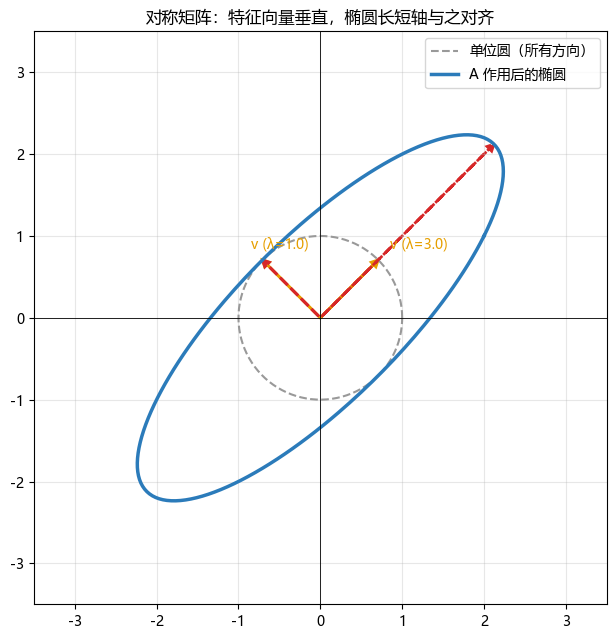

In [13]:
def 可视化特征向量(A, 标题="特征向量：变换后方向不变的向量"):
    λs, Vs = np.linalg.eig(A)
    θ = np.linspace(0, 2*np.pi, 300)
    圆 = np.vstack([np.cos(θ), np.sin(θ)])       # 单位圆（所有方向的单位向量）
    像 = A @ 圆                                    # A 作用后的椭圆

    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.plot(圆[0], 圆[1], '--', color=灰, lw=1.5, label='单位圆（所有方向）')
    ax.plot(像[0], 像[1], color=蓝, lw=2.5, label='A 作用后的椭圆')

    for λ, v in zip(λs, Vs.T):
        if np.iscomplexobj(λ) or np.iscomplexobj(v):
            continue
        λ, v = float(λ.real), v.real
        v = v / np.linalg.norm(v)
        ax.arrow(0, 0, v[0], v[1], head_width=0.08, head_length=0.08,
                 fc=橙, ec=橙, length_includes_head=True, lw=2)
        ax.arrow(0, 0, λ*v[0], λ*v[1], head_width=0.08, head_length=0.08,
                 fc='#d62728', ec='#d62728', length_includes_head=True, lw=2, ls='--')
        ax.text(v[0]*1.2, v[1]*1.2, f'v (λ={λ:.1f})', color=橙, fontsize=10)

    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)
    ax.legend(loc='upper right')
    ax.set_title(标题, fontsize=12)
    plt.tight_layout()
    plt.show()

可视化特征向量(np.array([[2, 1], [1, 2]]), "对称矩阵：特征向量垂直，椭圆长短轴与之对齐")

# 🌇 下午部分：SVD / PCA / 梯度

## 7. 基变换（PCA 的思想基础）

同一个"箭头"（向量），**换一组坐标轴看，坐标就变了，但箭头本身没变**。

- **标准基**：$\hat{i}=(1,0),\hat{j}=(0,1)$，我们平时默认用它；
- **新基**：换成另外两个不共线的向量 $\vec{b}_1,\vec{b}_2$ 当坐标轴；
- 若新基写成矩阵 $P$（列 = 新基向量），那么**标准坐标 $\vec{x}$ 和新基坐标 $\vec{y}$ 的关系**是 $\vec{x}=P\vec{y}$，即 $\vec{y}=P^{-1}\vec{x}$。

> **为什么和 PCA 有关？** PCA 的本质就是：**找一组"更好的基"（主成分方向），把数据重新表示，让最重要的信息集中在前几个坐标上**，从而实现降维。


新基向量 b1 = [2 1]    b2 = [-1  1]
基变换矩阵 P =
 [[ 2 -1]
 [ 1  1]]

标准坐标 v = [1 3]
新基下的坐标 = [1.33333333 1.66666667]   （含义：v = c1·b1 + c2·b2）
验证 P·v_新基 = [1. 3.] = v ✓


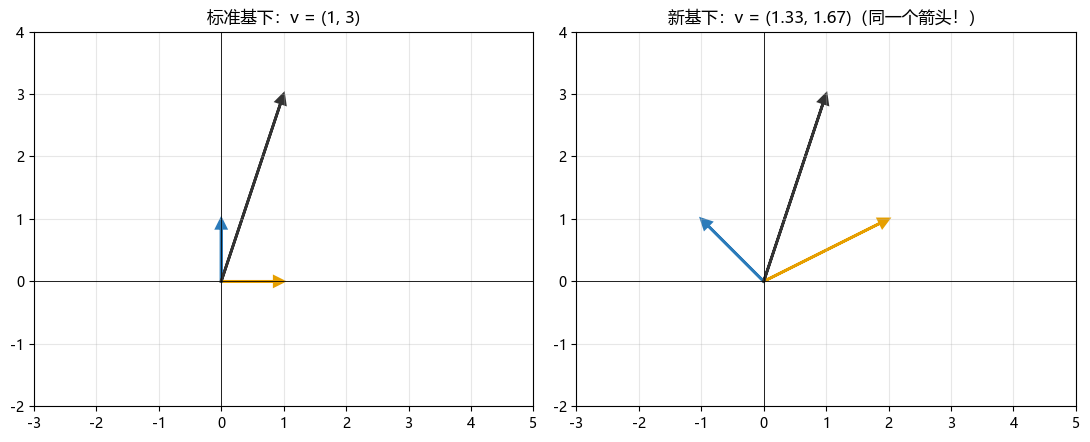

In [14]:
# ---- 基变换：同一个向量，换个坐标系看 ----
b1 = np.array([2, 1])     # 新坐标系的第一个基向量（用标准坐标描述）
b2 = np.array([-1, 1])    # 第二个基向量

P = np.column_stack([b1, b2])        # 基变换矩阵：列 = 新基向量
print("新基向量 b1 =", b1, "   b2 =", b2)
print("基变换矩阵 P =\n", P)

v_标准 = np.array([1, 3])             # 标准坐标下的向量
v_新基 = np.linalg.solve(P, v_标准)    # 解 P · v_新基 = v_标准；np.linalg.solve()作用：求解线性方程组
print("\n标准坐标 v =", v_标准)
print("新基下的坐标 =", v_新基, "  （含义：v = c1·b1 + c2·b2）")
print("验证 P·v_新基 =", P @ v_新基, "= v ✓")

# 可视化：左边标准基，右边新基（箭头是同一个）
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 5))
for ax in (ax0, ax1):
    ax.set_xlim(-3, 5); ax.set_ylim(-2, 4)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)

ax0.arrow(0, 0, 1, 0, head_width=0.15, head_length=0.15, fc=橙, ec=橙, length_includes_head=True, lw=2)
ax0.arrow(0, 0, 0, 1, head_width=0.15, head_length=0.15, fc=蓝, ec=蓝, length_includes_head=True, lw=2)
ax0.arrow(0, 0, v_标准[0], v_标准[1], head_width=0.15, head_length=0.15, fc='#333', ec='#333', length_includes_head=True, lw=2)
ax0.set_title('标准基下：v = (1, 3)')

ax1.arrow(0, 0, b1[0], b1[1], head_width=0.15, head_length=0.15, fc=橙, ec=橙, length_includes_head=True, lw=2)
ax1.arrow(0, 0, b2[0], b2[1], head_width=0.15, head_length=0.15, fc=蓝, ec=蓝, length_includes_head=True, lw=2)
ax1.arrow(0, 0, v_标准[0], v_标准[1], head_width=0.15, head_length=0.15, fc='#333', ec='#333', length_includes_head=True, lw=2)
ax1.set_title(f'新基下：v = ({v_新基[0]:.2f}, {v_新基[1]:.2f})（同一个箭头！）')
plt.tight_layout()
plt.show()

## 8. 矩阵分解：SVD（奇异值分解）

任何 $m\times n$ 矩阵 $A$ 都能分解成三块：

$$A \;=\; U\,\Sigma\,V^{T}$$

- $U$（$m\times m$）：**正交矩阵**，代表"旋转/镜像"（保持长度）；
- $\Sigma$（$m\times n$）：**对角矩阵**，对角元 $\sigma_1\ge\sigma_2\ge\dots\ge 0$ 叫**奇异值**，代表"沿各轴拉伸"；
- $V^T$（$n\times n$）：**正交矩阵**，代表"先旋转/镜像"。

**几何意义（美到爆炸）**：任意线性变换 $A$，都等价于——

$$\text{先旋转}(V^T)\;\rightarrow\;\text{沿坐标轴拉伸}(\Sigma)\;\rightarrow\;\text{再旋转}(U)$$

也就是说：**"任何线性变换 = 旋转 + 拉伸 + 旋转"**，没有一个例外。

**和特征值的联系**：奇异值 $\sigma_i=\sqrt{\text{特征值}(A^TA)}$；若 $A$ 是对称矩阵，奇异值就是特征值的绝对值。

**为什么有用？** SVD 是 PCA、推荐系统、图像压缩、伪逆求解等一票算法的底层工具。


A =
 [[3 1]
 [1 2]]

U =
 [[-0.851 -0.526]
 [-0.526  0.851]]

奇异值 σ = [3.618 1.382]

Σ =
 [[3.61803399 0.        ]
 [0.         1.38196601]]

Vᵀ =
 [[-0.851 -0.526]
 [-0.526  0.851]]

U·Σ·Vᵀ =
 [[3. 1.]
 [1. 2.]]
重建是否等于 A？ True


C:\Users\HP\AppData\Local\Temp\ipykernel_21544\3325183156.py:31: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()


D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


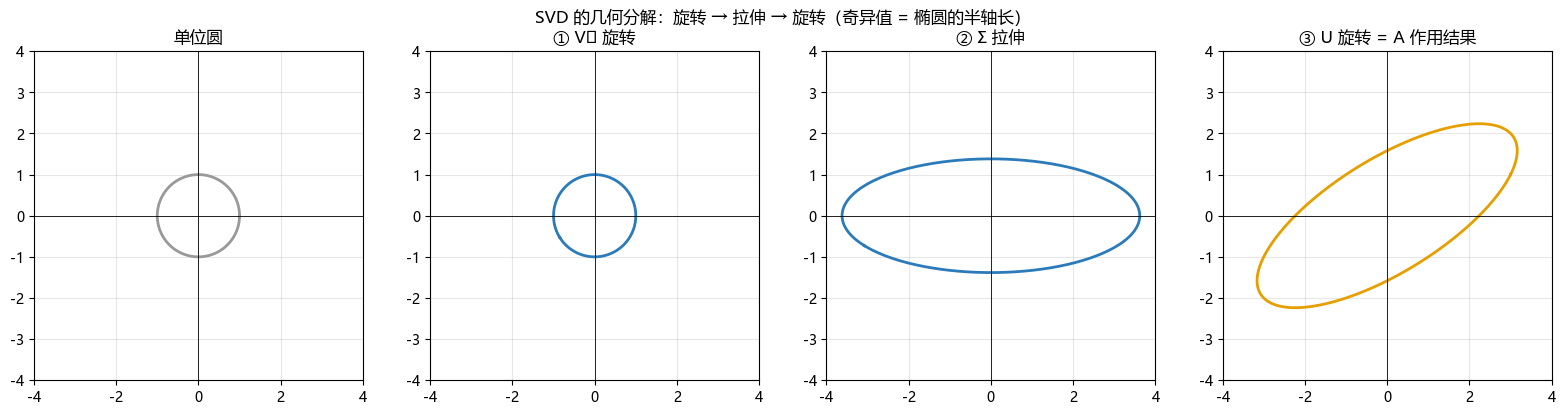

In [15]:
# ---- SVD：A = U Σ Vᵀ ----
A = np.array([[3, 1], [1, 2]])
U, S, Vt = np.linalg.svd(A)   #SVD分解
Σ = np.diag(S)              #把奇异值一维数组转化为对称矩阵

print("A =\n", A)
print("\nU =\n", np.round(U, 3))
print("\n奇异值 σ =", np.round(S, 3))
print("\nΣ =\n", Σ)
print("\nVᵀ =\n", np.round(Vt, 3))

重建 = U @ Σ @ Vt
print("\nU·Σ·Vᵀ =\n", np.round(重建, 3))
print("重建是否等于 A？", np.allclose(A, 重建))

# 几何分解：单位圆 → Vᵀ旋转 → Σ拉伸 → U旋转 = A 的结果
θ = np.linspace(0, 2*np.pi, 300)
圆 = np.vstack([np.cos(θ), np.sin(θ)])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
阶段 = [('单位圆', 圆, 灰),
        ('① Vᵀ 旋转', Vt @ 圆, 蓝),
        ('② Σ 拉伸', Σ @ Vt @ 圆, 蓝),
        ('③ U 旋转 = A 作用结果', U @ Σ @ Vt @ 圆, 橙)]
for ax, (name, pts, color) in zip(axes, 阶段):
    ax.plot(pts[0], pts[1], color=color, lw=2)
    ax.set_aspect('equal'); ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)
    ax.grid(alpha=0.3); ax.set_title(name)
fig.suptitle('SVD 的几何分解：旋转 → 拉伸 → 旋转（奇异值 = 椭圆的半轴长）', fontsize=12)
plt.tight_layout()
plt.show()

## 9. PCA 降维原理

**PCA（主成分分析）想干一件事**：数据里很多特征之间有冗余（相关性），能不能用**更少的维度**把信息尽量留住？

直觉上，就是找**数据"摊得最开"（方差最大）的方向**——信息主要分布在这个方向上。

**三步推导：**

1. **中心化**：把数据平移到均值 0（PCA 的前提，否则方差无意义）即把每一列的数据减去这一列的平均值；
2. **协方差矩阵** $C=\frac{1}{n-1}X^TX$：它记录了"每个维度的方差 + 两两之间的相关性"；
3. **特征分解 $C$**：$C$ 的**特征向量 = 主成分方向**（互相垂直），**特征值 = 沿该方向的方差**。

于是：**把特征值从大到小排，取前 $k$ 个特征向量当新坐标轴，把数据投影上去，就完成了降维**——保留的方差占比 = 前 $k$ 个特征值之和 ÷ 全部特征值之和。


协方差矩阵 =
 [[4.182 0.693]
 [0.693 0.931]]
对角线 = 各维度方差；非对角线 = 两维度的协方差（相关程度）

主成分（按方差占比从大到小）：
  主成分 1：方向 = [0.97978118 0.20007208], 方差(特征值) = 4.323, 占比 = 84.6%
  主成分 2：方向 = [-0.20007208  0.97978118], 方差(特征值) = 0.790, 占比 = 15.4%


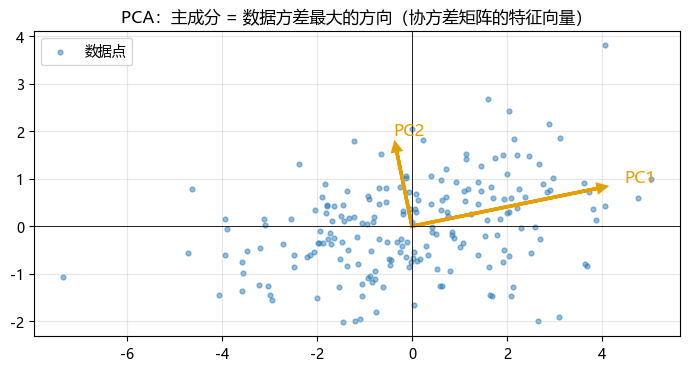

In [16]:
# ---- PCA：找方差最大的方向 ----
np.random.seed(42)
基础 = np.random.randn(200, 2)                 # 独立标准正态
变换 = np.array([[2.0, 0.8], [0.0, 1.0]])      # 引入相关：x 和 y 同涨同跌
数据 = 基础 @ 变换.T
数据 = 数据 - 数据.mean(axis=0)                 # 中心化（PCA 前提）

协方差 = (数据.T @ 数据) / (len(数据) - 1)
print("协方差矩阵 =\n", np.round(协方差, 3))
print("对角线 = 各维度方差；非对角线 = 两维度的协方差（相关程度）")

特征值, 特征向量 = np.linalg.eig(协方差)
顺序 = np.argsort(特征值)[::-1]                 # 按特征值从大到小
特征值 = 特征值[顺序]
特征向量 = 特征向量[:, 顺序]

print("\n主成分（按方差占比从大到小）：")
for i in range(2):
    print(f"  主成分 {i+1}：方向 = {特征向量[:, i]}, 方差(特征值) = {特征值[i]:.3f}, "
          f"占比 = {特征值[i]/特征值.sum():.1%}")

# 可视化：数据点 + 主成分方向
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(数据[:, 0], 数据[:, 1], s=12, alpha=0.5, color=蓝, label='数据点')
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)
for i in range(2):
    pc = 特征向量[:, i]
    L = 2 * np.sqrt(特征值[i])                   # 长度正比于标准差
    ax.arrow(0, 0, pc[0]*L, pc[1]*L, head_width=0.15, head_length=0.15,
             fc=橙, ec=橙, length_includes_head=True, lw=2.5)
    ax.text(pc[0]*L*1.1, pc[1]*L*1.1, f'PC{i+1}', color=橙, fontsize=12)
ax.set_title('PCA：主成分 = 数据方差最大的方向（协方差矩阵的特征向量）')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 10. 用 NumPy 从零实现 PCA

上面已经把原理讲完了，实现只需要**三行核心**：

```python
Xc = X - X.mean(axis=0)                     # 1. 中心化
C  = Xc.T @ Xc / (len(Xc) - 1)              # 2. 协方差矩阵
特征值, 特征向量 = np.linalg.eigh(C)          # 3. 特征分解
```

下面把它封装成一个和 sklearn 接口一致的 `fit / transform` 类，方便对比。


In [17]:
class 手写PCA:
    """从零实现 PCA（只依赖 NumPy）。核心就三步：中心化 → 协方差 → 特征分解。"""
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_                            # 1. 中心化
        协方差 = Xc.T @ Xc / (len(Xc) - 1)              # 2. 协方差矩阵
        特征值, 特征向量 = np.linalg.eigh(协方差)         # 3. 特征分解（eigh 返回升序）
        idx = np.argsort(特征值)[::-1]                   # 按方差从大到小
        self.特征值_ = 特征值[idx]
        self.components_ = 特征向量[:, idx].T            # 每行 = 一个主成分方向
        self.解释方差比_ = self.特征值_ / self.特征值_.sum()
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        Xc = X - self.mean_
        return Xc @ self.components_[:self.n_components].T   # 投影到前 k 个主成分

# 用刚才的二维数据测试
pca = 手写PCA(n_components=1).fit(数据)
降维后 = pca.transform(数据)

print("主成分方向 components_ =\n", np.round(pca.components_, 3))
print("各主成分解释的方差占比 =", np.round(pca.解释方差比_, 3))
print("降维后形状：", 数据.shape, "→", 降维后.shape)

主成分方向 components_ =
 [[-0.98 -0.2 ]
 [ 0.2  -0.98]]
各主成分解释的方差占比 = [0.846 0.154]
降维后形状： (200, 2) → (200, 1)


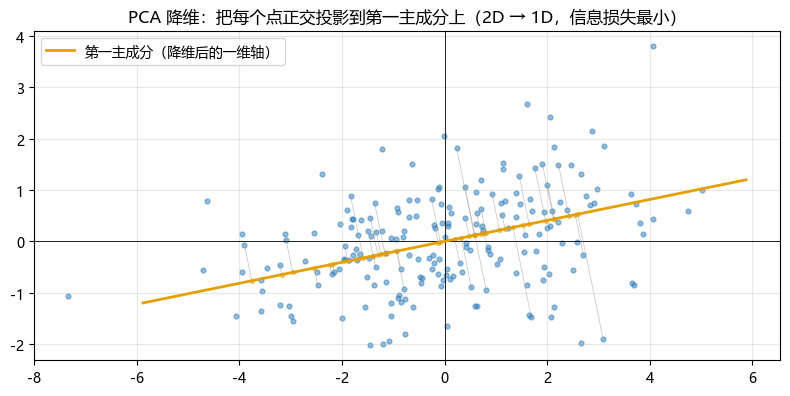

保留的方差占比 = 84.6%，即丢掉第二主成分后，数据仍保留了绝大部分信息。


In [18]:
# ---- PCA 降维可视化：2D → 1D ----
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(数据[:, 0], 数据[:, 1], s=12, alpha=0.5, color=蓝)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)

pc1 = pca.components_[0]
t = np.linspace(-6, 6, 2)
ax.plot(pc1[0]*t, pc1[1]*t, color=橙, lw=2, label='第一主成分（降维后的一维轴）')

for x, y in 数据[::5]:                        # 每隔 5 个点画一次，避免太密
    投影 = (np.array([x, y]) @ pc1) * pc1      # 正交投影到主成分方向
    ax.plot([x, 投影[0]], [y, 投影[1]], color=灰, lw=0.5, alpha=0.6)
    ax.scatter(投影[0], 投影[1], color=橙, s=8, alpha=0.5)

ax.legend()
ax.set_title('PCA 降维：把每个点正交投影到第一主成分上（2D → 1D，信息损失最小）')
plt.tight_layout()
plt.show()

print(f"保留的方差占比 = {pca.解释方差比_[0]:.1%}，"
      "即丢掉第二主成分后，数据仍保留了绝大部分信息。")

原数据 4 维，降到 2 维
前两个主成分解释的方差占比 = [0.925 0.053]


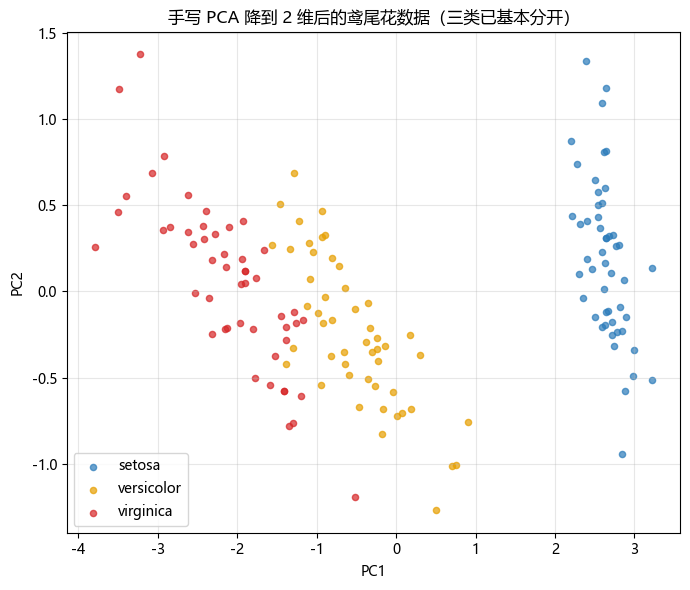

In [19]:
# ---- 用真实数据验证：鸢尾花数据集（4 维 → 2 维）----
try:
    from sklearn.datasets import load_iris
    iris = load_iris()
    X, y = iris.data, iris.target

    pca2 = 手写PCA(n_components=2).fit(X)
    X2 = pca2.transform(X)

    print("原数据 4 维，降到 2 维")
    print("前两个主成分解释的方差占比 =", np.round(pca2.解释方差比_[:2], 3))

    fig, ax = plt.subplots(figsize=(7, 6))
    颜色 = [蓝, 橙, '#d62728']
    for i, 名 in enumerate(iris.target_names):
        ax.scatter(X2[y == i, 0], X2[y == i, 1], s=20, alpha=0.7, color=颜色[i], label=名)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(); ax.grid(alpha=0.3)
    ax.set_title('手写 PCA 降到 2 维后的鸢尾花数据（三类已基本分开）')
    plt.tight_layout()
    plt.show()
except ImportError:
    print("sklearn 未安装，跳过真实数据示例。")

# 📉 第三部分：微积分与梯度

## 11. 梯度：指向函数"增长最快"的方向

一元函数有**导数** $f'(x)$（斜率）；到了多元函数，每个方向都有不同的变化率，于是引入：

$$\nabla f = \begin{bmatrix}\frac{\partial f}{\partial x}\\[4pt]\frac{\partial f}{\partial y}\end{bmatrix}$$

**梯度 $\nabla f$** 是一个**向量**，它有两个关键性质：

1. **方向**：指向函数值**增长最快**的方向；
2. **大小**：等于沿那个方向的**最大变化率**（最陡的坡）。

而且梯度方向**处处垂直于等高线**（等高线是函数值相等的曲线）。

> 这直接引出机器学习的核心算法——**梯度下降**：想找函数最小值，就**每次朝负梯度方向走一小步** $x \leftarrow x-\eta\nabla f(x)$。


C:\Users\HP\AppData\Local\Temp\ipykernel_21544\2283472113.py:21: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


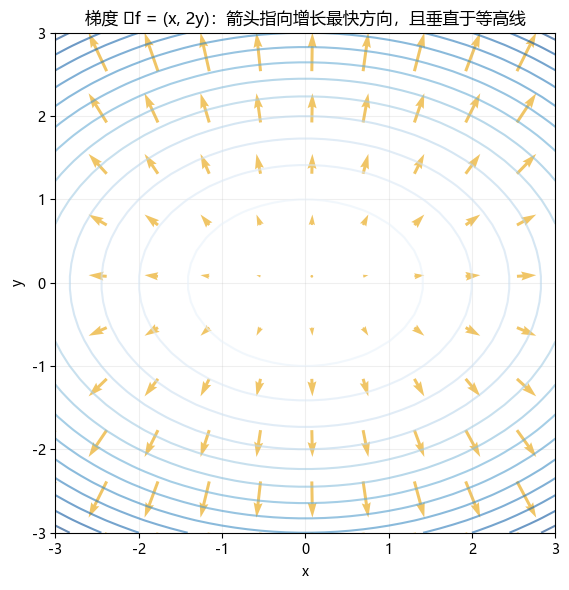

In [20]:
# ---- 梯度场：∇f 指向增长最快、垂直于等高线 ----
def f(x, y):
    return 0.5 * (x**2 + 2 * y**2)       # 一个"椭圆碗"函数

xs = np.linspace(-3, 3, 40)
ys = np.linspace(-3, 3, 40)
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(X, Y, Z, levels=15, cmap='Blues', alpha=0.6)

# 梯度 ∇f = (∂f/∂x, ∂f/∂y) = (x, 2y)
Gx, Gy = X, 2 * Y
sl = (slice(None, None, 4), slice(None, None, 4))   # 抽样，避免箭头太密
ax.quiver(X[sl], Y[sl], Gx[sl], Gy[sl], color=橙, alpha=0.6)

ax.set_aspect('equal'); ax.grid(alpha=0.2)
ax.set_title('梯度 ∇f = (x, 2y)：箭头指向增长最快方向，且垂直于等高线')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

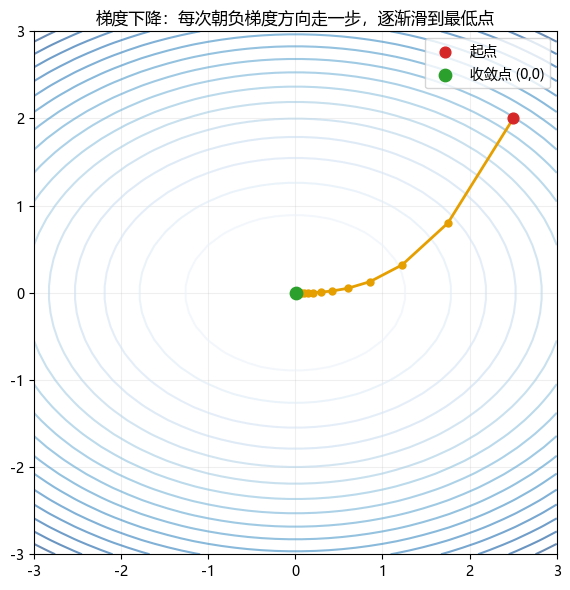

In [21]:
# ---- 梯度下降：沿负梯度方向一步步走向最低点 ----
def 梯度(x, y):
    return np.array([x, 2 * y])          # ∇f = (x, 2y)

点 = np.array([2.5, 2.0])                # 起点
学习率 = 0.3
轨迹 = [点.copy()]

for _ in range(15):
    点 = 点 - 学习率 * 梯度(*点)          # x ← x - η ∇f
    轨迹.append(点.copy())
轨迹 = np.array(轨迹)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(X, Y, Z, levels=20, cmap='Blues', alpha=0.6)
ax.plot(轨迹[:, 0], 轨迹[:, 1], 'o-', color=橙, lw=2, ms=5)
ax.scatter(*轨迹[0], color='#d62728', s=60, zorder=5, label='起点')
ax.scatter(*轨迹[-1], color='#2ca02c', s=80, zorder=5, label='收敛点 (0,0)')
ax.set_aspect('equal'); ax.grid(alpha=0.2)
ax.legend(); ax.set_title('梯度下降：每次朝负梯度方向走一步，逐渐滑到最低点')
plt.tight_layout()
plt.show()

## 12. Jacobian 矩阵：向量值函数的"一阶导"

梯度只描述**标量**函数 $f:\mathbb{R}^n\to\mathbb{R}$。如果函数输出也是**向量** $f:\mathbb{R}^n\to\mathbb{R}^m$（比如极坐标变换、神经网络的某一层），就把所有一阶偏导数排成一个矩阵：

$$J = \begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n}\\
\vdots & \ddots & \vdots\\
\frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n}
\end{bmatrix}, \qquad J_{ij}=\frac{\partial f_i}{\partial x_j}$$

**直觉**：$J$ 是 $f$ 在某一点附近的**"局部线性化"矩阵**（和一元函数的切线斜率完全同构）。$J$ 的行向量是各个分量函数的梯度；$|\det J|$ 是该点附近**局部面积/体积的缩放因子**。


In [22]:
# ---- Jacobian：向量值函数的一阶导（极坐标变换为例）----
def f极坐标(u):
    r, θ = u
    return np.array([r * np.cos(θ), r * np.sin(θ)])   # (r,θ) → (x,y)

def 数值雅可比(f, u, h=1e-6):
    """中心差分数值计算 Jacobian（不必手推公式）。"""
    u = np.asarray(u, dtype=float)
    J = np.zeros((len(f(u)), len(u)))
    for j in range(len(u)):
        扰动 = np.zeros_like(u); 扰动[j] = h
        J[:, j] = (f(u + 扰动) - f(u - 扰动)) / (2 * h)
    return J

u0 = np.array([2.0, np.pi / 4])            # r=2, θ=45°
J = 数值雅可比(f极坐标, u0)
print("在 (r=2, θ=45°) 处的 Jacobian J =\n", np.round(J, 4))

解析解 = np.array([[np.cos(np.pi/4), -2*np.sin(np.pi/4)],
                   [np.sin(np.pi/4),  2*np.cos(np.pi/4)]])
print("\n解析解 J = [[cosθ, -r sinθ],\n           [sinθ,  r cosθ]] =\n", np.round(解析解, 4))
print("\n数值解 ≈ 解析解 ✓")
print("det(J) =", round(np.linalg.det(J), 4), "= r，正是极坐标把面积放大的倍数。")

在 (r=2, θ=45°) 处的 Jacobian J =
 [[ 0.7071 -1.4142]
 [ 0.7071  1.4142]]

解析解 J = [[cosθ, -r sinθ],
           [sinθ,  r cosθ]] =
 [[ 0.7071 -1.4142]
 [ 0.7071  1.4142]]

数值解 ≈ 解析解 ✓
det(J) = 2.0 = r，正是极坐标把面积放大的倍数。


## 13. Hessian 矩阵：标量函数的"二阶导"

把标量函数 $f:\mathbb{R}^n\to\mathbb{R}$ 的二阶偏导数也排成一个矩阵：

$$H = \begin{bmatrix}
\frac{\partial^2 f}{\partial x_1^2} & \cdots & \frac{\partial^2 f}{\partial x_1\partial x_n}\\
\vdots & \ddots & \vdots\\
\frac{\partial^2 f}{\partial x_n\partial x_1} & \cdots & \frac{\partial^2 f}{\partial x_n^2}
\end{bmatrix}, \qquad H_{ij}=\frac{\partial^2 f}{\partial x_i\partial x_j}$$

**直觉**：$H$ 描述函数在某点附近的**曲率**（"弯得有多快"），是对一元函数"二阶导"的推广。$H$ 是**对称矩阵**（$\frac{\partial^2 f}{\partial x_i\partial x_j}=\frac{\partial^2 f}{\partial x_j\partial x_i}$）。

**用途（优化里非常重要）：**

- $H$ **正定** → 局部**极小点**；$H$ **负定** → 局部**极大点**；不定 → **鞍点**；
- 判断一个临界点是不是最小值点，就看 $H$ 的正定性；
- **牛顿法**、二阶优化器（如部分深度学习优化算法）都用到 $H$ 或它的近似。


In [23]:
# ---- Hessian：标量函数的二阶导 ----
def g(x):
    x0, x1 = x
    return x0**2 + 3 * x1**2 + x0 * x1      # 含交叉项，Hessian 会有非对角元

def 数值Hessian(g, x, h=1e-4):
    """有限差分数值计算 Hessian。"""
    x = np.asarray(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei, ej = np.zeros(n), np.zeros(n)
            ei[i] = h; ej[j] = h
            H[i, j] = (g(x + ei + ej) - g(x + ei - ej)
                       - g(x - ei + ej) + g(x - ei - ej)) / (4 * h * h)
    return H

H = 数值Hessian(g, np.array([0.0, 0.0]))
print("g(x,y) = x² + 3y² + xy")
print("Hessian H =\n", np.round(H, 2))
print("\n解析解 H = [[2, 1],\n         [1, 6]]  → 数值解吻合 ✓")

特征值 = np.linalg.eigvalsh(H)
print("\nH 的特征值 =", np.round(特征值, 3), " 全部 > 0 → H 正定 → (0,0) 是局部极小点。")

g(x,y) = x² + 3y² + xy
Hessian H =
 [[2. 1.]
 [1. 6.]]

解析解 H = [[2, 1],
         [1, 6]]  → 数值解吻合 ✓

H 的特征值 = [1.764 6.236]  全部 > 0 → H 正定 → (0,0) 是局部极小点。


# 🎯 总结

## 线性代数（一图串起来）

| 概念 | 一句话直觉 | 关键公式 / 事实 |
| --- | --- | --- |
| **点积** | 一个数 = 投影 × 长度 | $\vec{v}\cdot\vec{w}=|\vec{v}||\vec{w}|\cos\theta$ |
| **矩阵乘法** | 复合变换，顺序重要 | $(AB)\vec{x}=A(B\vec{x})$，一般 $AB\ne BA$ |
| **线性变换** | 空间"揉捏"，由基向量去向决定 | 矩阵的列 = 新基向量 |
| **行列式** | 面积的缩放倍数 | $\det=0$ 表示被压扁、不可逆 |
| **特征值/向量** | 方向不变、只被拉伸 | $A\vec{v}=\lambda\vec{v}$ |
| **基变换** | 换个坐标系看同一向量 | $\vec{x}=P\vec{y}$ |
| **SVD** | 任何变换 = 旋转+拉伸+旋转 | $A=U\Sigma V^T$ |
| **PCA** | 找方差最大的方向降维 | 协方差矩阵的特征向量 |

## 微积分（梯度族三兄弟）

| 概念 | 作用对象 | 形状 | 含义 |
| --- | --- | --- | --- |
| **梯度** $\nabla f$ | 标量函数 $f:\mathbb{R}^n\to\mathbb{R}$ | 向量 | 增长最快的方向 |
| **Jacobian** $J$ | 向量函数 $f:\mathbb{R}^n\to\mathbb{R}^m$ | $m\times n$ 矩阵 | 一阶导 / 局部线性化 |
| **Hessian** $H$ | 标量函数 $f:\mathbb{R}^n\to\mathbb{R}$ | $n\times n$ 对称矩阵 | 二阶导 / 曲率 |

## 一句话记住整篇

> 矩阵是"动作"，特征向量是"不变的方向"，SVD 把动作拆成"旋转+拉伸+旋转"，PCA 用特征向量给数据换一套更好的坐标系来降维；梯度告诉我们往哪个方向爬升，Jacobian/Hessian 是多维世界里的一阶、二阶导数。

**把 SVD 和 PCA 那几段代码多跑几遍**——手写一遍 PCA 之后，你会比看十遍视频都更懂"降维"到底在做什么。
